<a href="https://colab.research.google.com/github/korkutanapa/OEE_ARTICLE_STUDIES/blob/main/GM2_Decomposition_HeatKernel_Seperate_Points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIBRARIES

In [ ]:
%pip install -q "numpy==1.26.4" "scipy==1.11.4" "scikit-learn==1.3.2"
%pip install -q "giotto-tda==0.6.2"

In [ ]:
# Install feature_engine (run this once in a cell)
%pip install feature_engine

In [ ]:
!pip install pmdarima

In [ ]:
%pip install pyswarm

# READING THE FILES

In [1]:
import pandas as pd

# --- 1. Set the file path ---
# For Colab or local environment, adjust as needed
data_path = "/content/GM2.xlsx"   # or "TRIAL_SET_10_GM2ts.xlsx"

# --- 2. Read the Excel file ---
df = pd.read_excel(data_path)

# --- 3. (Optional) Parse datetime column & set index ---
# Change "DateTime" to the actual name of your time column if different
if "DateTime" in df.columns:
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime")

# --- 4. Select the main target column ---
# Change "Operation" if your target column has another name
target_col = "Operation"
ts = df[target_col].astype(float)

print("Data shape:", df.shape)
print(df.head())


Data shape: (667, 1)
                     Operation
DateTime                      
2024-08-14 00:00:00         60
2024-08-14 01:00:00         60
2024-08-14 02:00:00         60
2024-08-14 03:00:00         60
2024-08-14 04:00:00         60


# DECOMPOSITION

In [2]:
data = df.copy()

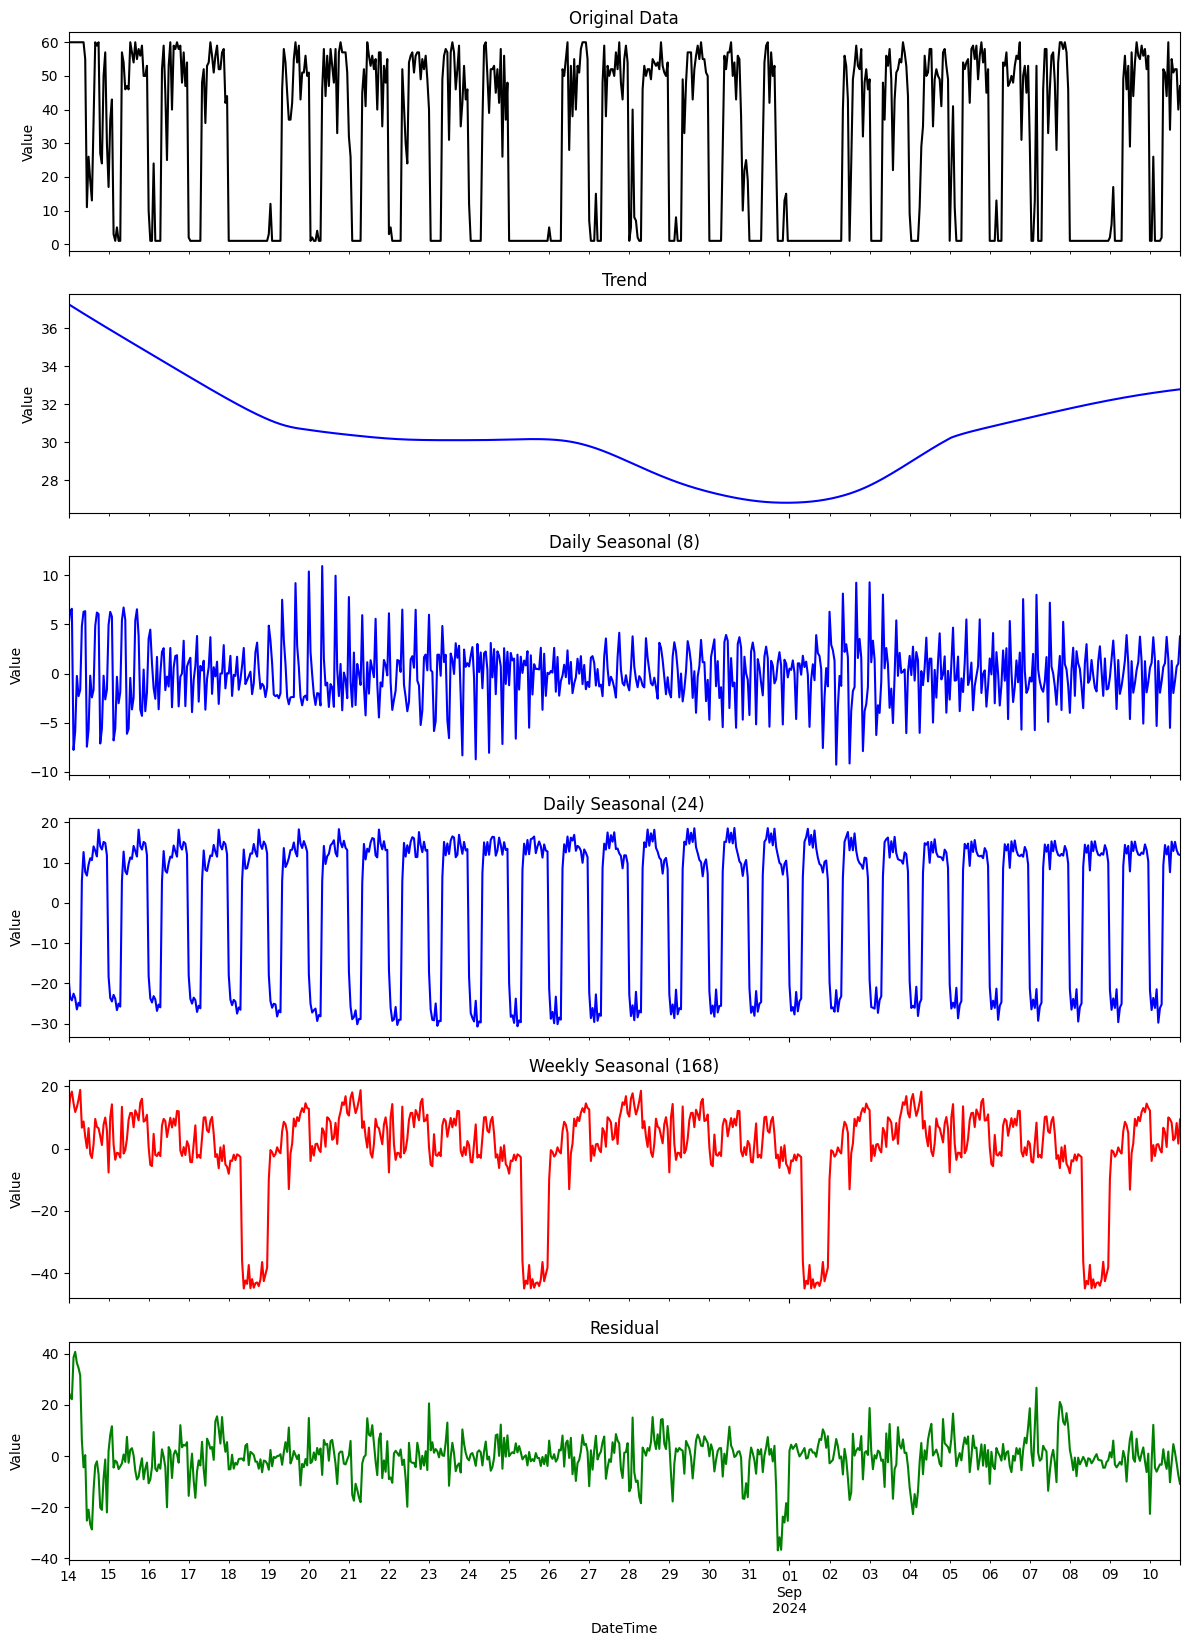

In [3]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# Ensure the data is sorted by time
data = data.sort_index()

# MSTL decomposition
stl_kwargs = {"seasonal_deg": 0}
model = MSTL(data['Operation'], periods=(8, 24, 168), stl_kwargs=stl_kwargs)
res = model.fit()

# Extracting the seasonal components
seasonal_8=res.seasonal.iloc[:, 0]
seasonal_24 = res.seasonal.iloc[:, 1]  # Daily seasonal component
seasonal_168 = res.seasonal.iloc[:, 2]  # Weekly seasonal component
trend = res.trend
residual = res.resid

# Plotting
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)

data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')


trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')


seasonal_8.plot(ax=axes[2], color='blue', title='Daily Seasonal (8)')
axes[2].set_ylabel('Value')


seasonal_24.plot(ax=axes[3], color='blue', title='Daily Seasonal (24)')
axes[3].set_ylabel('Value')


seasonal_168.plot(ax=axes[4], color='red', title='Weekly Seasonal (168)')
axes[4].set_ylabel('Value')


residual.plot(ax=axes[5], color='green', title='Residual')
axes[5].set_ylabel('Value')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [4]:
# Create DataFrames for each component
trend_df = pd.DataFrame({'Trend': trend})
seasonal_8_df = pd.DataFrame( {'Seasonal_8': seasonal_8})
seasonal_24_df = pd.DataFrame({ 'Seasonal_24': seasonal_24})
seasonal_168_df = pd.DataFrame({ 'Seasonal_168': seasonal_168})
residual_df = pd.DataFrame({ 'Operation': residual})

In [5]:
residual_df

,Operation
DateTime,
2024-08-14 00:00:00,25.459671
2024-08-14 01:00:00,23.330019
2024-08-14 02:00:00,22.204894
2024-08-14 03:00:00,38.603897
2024-08-14 04:00:00,40.754863
...,...
2024-09-10 14:00:00,4.666615
2024-09-10 15:00:00,1.450821
2024-09-10 16:00:00,-2.788435


In [7]:
import numpy as np

from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Define the ETS model (additive trend)
trend_model = ExponentialSmoothing(
    trend_df['Trend'],
    trend='add',  # Use 'mul' for multiplicative trend if appropriate
    seasonal=None,  # No seasonality for pure trend modeling
    damped_trend=False  # Set to True if a damped trend is preferred
)

# Fit the model
fitted_trend_model = trend_model.fit()

# Forecast the next 20 data points
trend_forecast = np.array(fitted_trend_model.forecast(5))
trend_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


array([32.79936851, 32.8099132 , 32.82045789, 32.83100258, 32.84154727])

In [8]:
# Forecast Seasonal (8) by repeating the last period's values
seasonal_8_forecast = np.tile(
    seasonal_8_df['Seasonal_8'][-8:].values,
    len(seasonal_8_df) // 8 + 1
)[:len(seasonal_8_df)]

In [9]:
# Forecast Seasonal (24) by repeating the last period's values
seasonal_24_forecast = np.tile(
    seasonal_24_df['Seasonal_24'][-24:].values,
    len(seasonal_24_df) // 24 + 1
)[:len(seasonal_24_df)]

In [10]:
# Forecast Seasonal (168) similarly
seasonal_168_forecast = np.tile(
    seasonal_168_df['Seasonal_168'][-168:].values,
    len(seasonal_168_df) // 168 + 1
)[:len(seasonal_168_df)]

In [14]:
import pandas as pd
import numpy as np

# Use the length of trend_forecast as horizon
h = len(trend_forecast)

# In case seasonal forecasts are longer (e.g., full history), take the last h values
seasonal_8_fc   = np.asarray(seasonal_8_forecast)[-h:]
seasonal_24_fc  = np.asarray(seasonal_24_forecast)[-h:]
seasonal_168_fc = np.asarray(seasonal_168_forecast)[-h:]

# 5) Build future index (preserve datetime index if possible)
last_index = ts.index[-1]

if isinstance(ts.index, pd.DatetimeIndex):
    inferred_freq = ts.index.inferred_freq
    if inferred_freq is None:
        # Fallback: use last observed step
        inferred_freq = ts.index[-1] - ts.index[-2]
        future_index = pd.date_range(
            start=last_index + inferred_freq,
            periods=h,
            freq=inferred_freq
        )
    else:
        future_index = pd.date_range(
            start=last_index,
            periods=h + 1,
            freq=inferred_freq
        )[1:]  # drop first (equals last_index)
else:
    future_index = pd.RangeIndex(start=len(ts), stop=len(ts) + h, step=1)

# 6) Assemble forecast DataFrame
next_forecasts = pd.DataFrame(
    {
        "trend_forecast":      np.asarray(trend_forecast),
        "seasonal_8_forecast": seasonal_8_fc,
        "seasonal_24_forecast": seasonal_24_fc,
        "seasonal_168_forecast": seasonal_168_fc,
    },
    index=future_index
)

# Combined forecast = trend + all seasonal components
next_forecasts["combined_forecast"] = (
    next_forecasts["trend_forecast"]
    + next_forecasts["seasonal_8_forecast"]
    + next_forecasts["seasonal_24_forecast"]
    + next_forecasts["seasonal_168_forecast"]
)

print(next_forecasts)


                     trend_forecast  seasonal_8_forecast  \
2024-09-10 19:00:00       32.799369             1.024581   
2024-09-10 20:00:00       32.809913             3.774953   
2024-09-10 21:00:00       32.820458             1.464787   
2024-09-10 22:00:00       32.831003            -5.514687   
2024-09-10 23:00:00       32.841547             1.295170   

                     seasonal_24_forecast  seasonal_168_forecast  \
2024-09-10 19:00:00             14.370970               5.190528   
2024-09-10 20:00:00             12.039378               0.510435   
2024-09-10 21:00:00             14.044138               9.997734   
2024-09-10 22:00:00              7.618331               9.431133   
2024-09-10 23:00:00             15.211292               8.291404   

                     combined_forecast  
2024-09-10 19:00:00          53.385448  
2024-09-10 20:00:00          49.134680  
2024-09-10 21:00:00          58.327117  
2024-09-10 22:00:00          44.365780  
2024-09-10 23:00:00      

# ANALYSIS OF RESIDUAL COMPONENT

Residual series shape: (667,)
DateTime
2024-08-14 00:00:00    25.459671
2024-08-14 01:00:00    23.330019
2024-08-14 02:00:00    22.204894
2024-08-14 03:00:00    38.603897
2024-08-14 04:00:00    40.754863
Name: Operation, dtype: float64


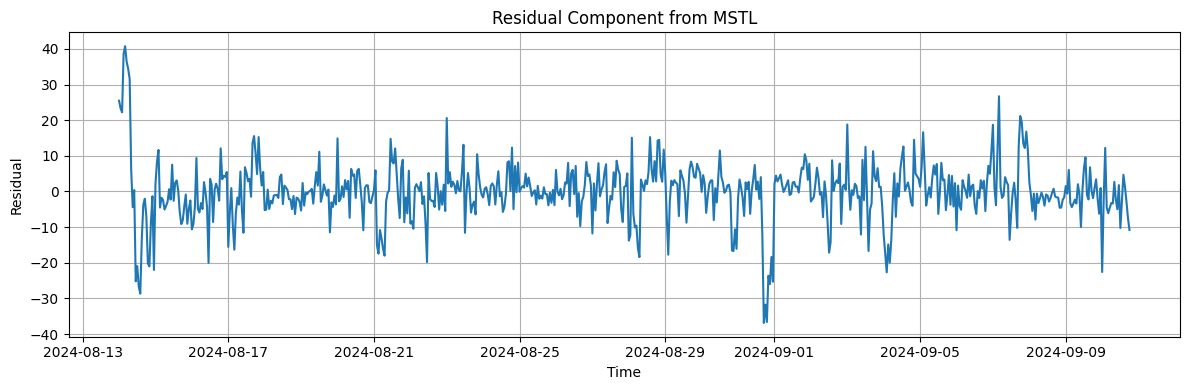

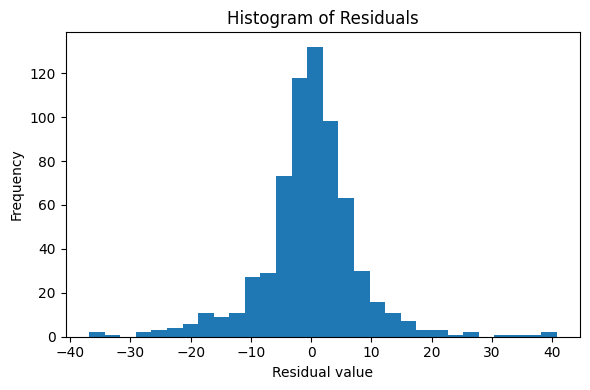

In [15]:
import matplotlib.pyplot as plt

# 1) Extract residual component
residual_series = residual_df["Operation"].astype(float)

print("Residual series shape:", residual_series.shape)
print(residual_series.head())

# 2) Plot residual vs time
plt.figure(figsize=(12, 4))
plt.plot(residual_series.index, residual_series.values)
plt.title("Residual Component from MSTL")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) (Optional) Plot histogram of residuals
plt.figure(figsize=(6, 4))
plt.hist(residual_series.values, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [16]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

# ------------------------------------
# Assume:
# residual_series = decomp_df["resid"].astype(float)
# ------------------------------------

residual_series = residual_series.dropna()

# 1) Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(residual_series, autolag="AIC")

adf_output = {
    "ADF Statistic": adf_result[0],
    "p-value": adf_result[1],
    "Used Lags": adf_result[2],
    "Number of Observations": adf_result[3],
    "Critical Values": adf_result[4]
}

print("\n===== ADF Test Results =====")
for k, v in adf_output.items():
    print(f"{k}: {v}")

if adf_result[1] < 0.05:
    print("✅ ADF: Series is STATIONARY (reject H0 of unit root)")
else:
    print("❌ ADF: Series is NON-STATIONARY (fail to reject H0)")

# 2) KPSS Test
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(residual_series, regression="c", nlags="auto")

kpss_output = {
    "KPSS Statistic": kpss_stat,
    "p-value": kpss_p,
    "Used Lags": kpss_lags,
    "Critical Values": kpss_crit
}

print("\n===== KPSS Test Results =====")
for k, v in kpss_output.items():
    print(f"{k}: {v}")

if kpss_p > 0.05:
    print("✅ KPSS: Series is STATIONARY (fail to reject H0)")
else:
    print("❌ KPSS: Series is NON-STATIONARY (reject H0)")



===== ADF Test Results =====
ADF Statistic: -5.169531445366495
p-value: 1.0142710401981985e-05
Used Lags: 20
Number of Observations: 646
Critical Values: {'1%': -3.4405132737812596, '5%': -2.8660244429195725, '10%': -2.5691581552588447}
✅ ADF: Series is STATIONARY (reject H0 of unit root)

===== KPSS Test Results =====
KPSS Statistic: 0.03103769450296112
p-value: 0.1
Used Lags: 13
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
✅ KPSS: Series is STATIONARY (fail to reject H0)


/tmp/ipython-input-2388671582.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(residual_series, regression="c", nlags="auto")


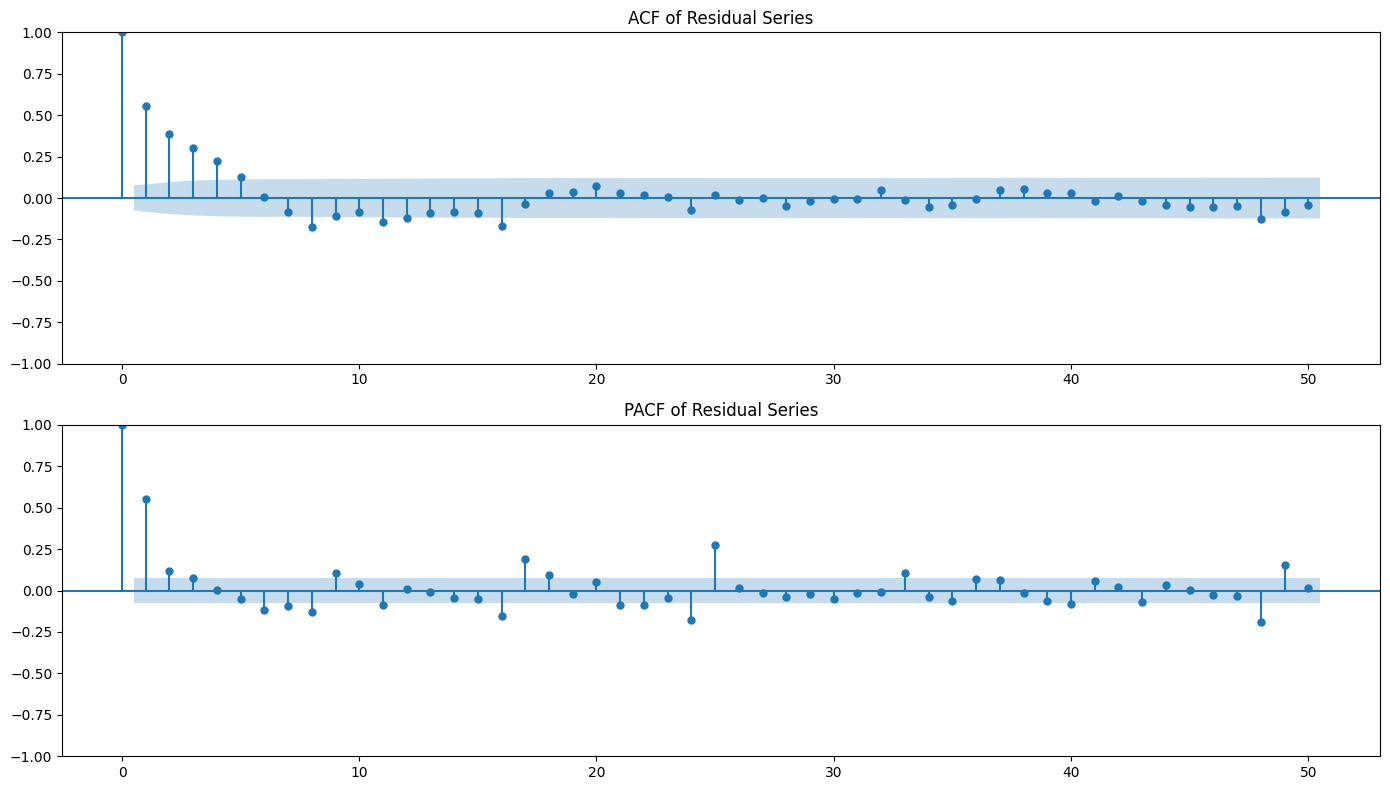

In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ------------------------------------
# Assume:
# residual_series = decomp_df["resid"].astype(float).dropna()
# ------------------------------------

# 1) Create figure
plt.figure(figsize=(14, 8))

# 2) ACF Plot
plt.subplot(2, 1, 1)
plot_acf(residual_series, lags=50, ax=plt.gca())
plt.title("ACF of Residual Series")

# 3) PACF Plot
plt.subplot(2, 1, 2)
plot_pacf(residual_series, lags=50, method="ywm", ax=plt.gca())
plt.title("PACF of Residual Series")

plt.tight_layout()
plt.show()


In [18]:
from pmdarima import auto_arima
import numpy as np

# ------------------------------------
# Assume:
# residual_series = decomp_df["resid"].astype(float).dropna()
# ------------------------------------

# 1) Ask user for remaining seasonality
while True:
    try:
        m = int(input("Enter the remaining seasonality period m (e.g. 8, 24, 168): "))
        if m < 2:
            print("m must be >= 2")
            continue
        break
    except ValueError:
        print("Invalid input. Please enter an integer (e.g. 8, 24, 168).")

print(f"\nRunning Auto-ARIMA with seasonal period m = {m}\n")

# 2) Run Auto-ARIMA
auto_model = auto_arima(
    residual_series,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    seasonal=True,
    m=m,
    d=None,          # let auto_arima decide
    D=None,          # let auto_arima decide
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

# 3) Print selected orders
print("\n==============================")
print("Best non-seasonal order (p,d,q):", auto_model.order)
print("Best seasonal order (P,D,Q,m):", auto_model.seasonal_order)
print("AIC:", auto_model.aic())
print("BIC:", auto_model.bic())
print("==============================\n")


Enter the remaining seasonality period m (e.g. 8, 24, 168): 8

Running Auto-ARIMA with seasonal period m = 8

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=4725.515, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4457.972, Time=1.12 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4507.765, Time=1.11 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=4723.699, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=4477.068, Time=0.19 sec
 ARIMA(1,0,0)(2,0,0)[8] intercept   : AIC=4411.182, Time=1.94 sec
 ARIMA(1,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=3.42 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.31 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=4671.223, Time=0.73 sec
 ARIMA(2,0,0)(2,0,0)[8] intercept   : AIC=4397.144, Time=1.46 sec
 ARIMA(2,0,0)(1,0,0)[8] intercept   : AIC=4448.399, Time=0.54 sec
 ARIMA(2,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=2.10 sec
 ARIMA(2,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.21 sec
 ARIMA(3,

In [19]:
# ------------------------------------
# Print Auto-ARIMA model summary
# ------------------------------------
print(auto_model.summary())


                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  667
Model:             SARIMAX(2, 0, 2)x(2, 0, 2, 8)   Log Likelihood               -2098.034
Date:                           Sat, 29 Nov 2025   AIC                           4214.068
Time:                                   19:47:02   BIC                           4254.593
Sample:                               08-14-2024   HQIC                          4229.768
                                    - 09-10-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6686      0.122     13.717      0.000       1.430       1.907
ar.L2         -0.6747      0.118     -5.729

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------------
# Assume:
# - auto_model is already fitted by pmdarima.auto_arima
# - residual_series = decomp_df["resid"].astype(float).dropna()
# ------------------------------------

# 1) Get suggested orders from auto_model
default_p, default_d, default_q = auto_model.order
default_P, default_D, default_Q, default_m = auto_model.seasonal_order

print("Auto-ARIMA suggested the following orders:")
print(f"  Non-seasonal (p, d, q): ({default_p}, {default_d}, {default_q})")
print(f"  Seasonal (P, D, Q, m):  ({default_P}, {default_D}, {default_Q}, {default_m})\n")

# 2) Helper function to ask user with default
def ask_int_with_default(prompt, default):
    s = input(f"{prompt} (press Enter to keep {default}): ").strip()
    if s == "":
        return default
    try:
        return int(s)
    except ValueError:
        print(f"Invalid input, using default = {default}")
        return default

# 3) Ask user for manual orders (or keep defaults)
print("You can now define the SARIMAX orders manually.")
print("If you are happy with Auto-ARIMA's suggestion, just press Enter for each field.\n")

p = ask_int_with_default("Enter p", default_p)
d = ask_int_with_default("Enter d", default_d)
q = ask_int_with_default("Enter q", default_q)

P = ask_int_with_default("Enter P (seasonal AR order)", default_P)
D = ask_int_with_default("Enter D (seasonal differencing)", default_D)
Q = ask_int_with_default("Enter Q (seasonal MA order)", default_Q)
m = ask_int_with_default("Enter m (seasonal period)", default_m)

manual_order = (p, d, q)
manual_seasonal_order = (P, D, Q, m)

print("\nUsing manual SARIMAX specification:")
print(f"  order = {manual_order}")
print(f"  seasonal_order = {manual_seasonal_order}\n")

# 4) Define and fit the SARIMAX model on residual_series
sarimax_res_model = SARIMAX(
    residual_series,
    order=manual_order,
    seasonal_order=manual_seasonal_order
)

sarimax_res_results = sarimax_res_model.fit(disp=False)

print("Manual SARIMAX model fitted. Summary:")
print(sarimax_res_results.summary())


Auto-ARIMA suggested the following orders:
  Non-seasonal (p, d, q): (2, 0, 2)
  Seasonal (P, D, Q, m):  (2, 0, 2, 8)

You can now define the SARIMAX orders manually.
If you are happy with Auto-ARIMA's suggestion, just press Enter for each field.

Enter p (press Enter to keep 2): 
Enter d (press Enter to keep 0): 
Enter q (press Enter to keep 2): 
Enter P (seasonal AR order) (press Enter to keep 2): 
Enter D (seasonal differencing) (press Enter to keep 0): 
Enter Q (seasonal MA order) (press Enter to keep 2): 
Enter m (seasonal period) (press Enter to keep 8): 

Using manual SARIMAX specification:
  order = (2, 0, 2)
  seasonal_order = (2, 0, 2, 8)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Manual SARIMAX model fitted. Summary:
                                     SARIMAX Results                                     
Dep. Variable:                         Operation   No. Observations:                  667
Model:             SARIMAX(2, 0, 2)x(2, 0, 2, 8)   Log Likelihood               -2098.034
Date:                           Sat, 29 Nov 2025   AIC                           4214.068
Time:                                   19:47:20   BIC                           4254.593
Sample:                               08-14-2024   HQIC                          4229.768
                                    - 09-10-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6686      0.122     13.717      0.000       1.430       1.907
ar.L2

# CREATE TOPOLOGICAL FEATURES

In [21]:
# Convert residual_series to DataFrame and rename column to 'Operation'
df = residual_series.to_frame(name="Operation")

print(df.head())
print("New DataFrame shape:", df.shape)


                     Operation
DateTime                      
2024-08-14 00:00:00  25.459671
2024-08-14 01:00:00  23.330019
2024-08-14 02:00:00  22.204894
2024-08-14 03:00:00  38.603897
2024-08-14 04:00:00  40.754863
New DataFrame shape: (667, 1)


In [22]:
df

,Operation
DateTime,
2024-08-14 00:00:00,25.459671
2024-08-14 01:00:00,23.330019
2024-08-14 02:00:00,22.204894
2024-08-14 03:00:00,38.603897
2024-08-14 04:00:00,40.754863
...,...
2024-09-10 14:00:00,4.666615
2024-09-10 15:00:00,1.450821
2024-09-10 16:00:00,-2.788435


In [23]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [24]:
import numpy as np
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# --- 1) Extract the time series as (n_timestamps, 1) ---
# df: your DataFrame, with a column 'Operation'
X = df['Operation'].to_numpy(dtype=float).reshape(-1, 1)   # shape: (n_timestamps, 1)

# --- 2) Sliding window: cut into overlapping windows ---
SW = SlidingWindow(size=window_size, stride=stride)
# Typical output shape: (n_windows, window_size, n_features)
X_sw = SW.fit_transform(X)

# For convenience, treat each window as an independent univariate series
n_windows, win_len, n_feat = X_sw.shape  # n_feat should be 1
X_windows = X_sw.reshape(n_windows, win_len)   # shape: (n_windows, window_size)

# --- 3) Takens embedding on each window ---
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
# Input: (n_windows, window_size)
# Output: (n_windows, n_points, dimension)
X_te = TE.fit_transform(X_windows)

# --- 4) Vietoris–Rips persistence on embedded windows ---
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
# Input: (n_windows, n_points, dimension)
# Output: array of diagrams, one per window
diagrams = VR.fit_transform(X_te)

# --- 5) Scale persistence diagrams (normalization in diagram space) ---
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [25]:
import numpy as np
import pandas as pd
from gtda.diagrams import HeatKernel

# -------------------------------------------------------------------
# Helper: heat kernel feature extraction
# -------------------------------------------------------------------
def extract_heat_kernel_features(heat_kernel_features):
    """
    heat_kernel_features: array of shape
        (n_windows, 2, n_bins, n_bins) for H0 and H1

    Returns:
        DataFrame (n_windows, many_features)
        Columns:
            HK_L1_H0, HK_L2_H0,
            HK_Col0_L1_H0, HK_Col0_L2_H0, ..., HK_Col(N-1)_L1_H0, HK_Col(N-1)_L2_H0,
            HK_L1_H1, HK_L2_H1,
            HK_Col0_L1_H1, HK_Col0_L2_H1, ..., HK_Col(N-1)_L1_H1, HK_Col(N-1)_L2_H1
    """
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # per window
        sample_feats = {}

        for dim_idx, hom_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim_idx, :, :]  # shape: (n_bins, n_bins)

            # Global L1/L2 norms over full matrix
            sample_feats[f"HK_L1_{hom_dim}"] = np.sum(np.abs(matrix))
            sample_feats[f"HK_L2_{hom_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column L1/L2 norms
            n_cols = matrix.shape[1]
            for col in range(n_cols):
                col_data = matrix[:, col]
                sample_feats[f"HK_Col{col}_L1_{hom_dim}"] = np.sum(np.abs(col_data))
                sample_feats[f"HK_Col{col}_L2_{hom_dim}"] = np.sqrt(
                    np.sum(col_data ** 2)
                )

        feature_list.append(sample_feats)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df


# -------------------------------------------------------------------
# Main: build HK-only windowed TDA feature matrix
# -------------------------------------------------------------------
def build_windowed_tda_feature_matrix(scaled_diagrams,
                                      heat_sigma=0.1,
                                      heat_bins=250):
    """
    HK-only version.

    Parameters
    ----------
    scaled_diagrams : array-like
        Persistence diagrams per window (compatible with gtda HeatKernel).
    heat_sigma : float
        Sigma parameter for HeatKernel.
    heat_bins : int
        Number of bins (n_bins) for HeatKernel.

    Returns
    -------
    heat_kernel_df : pd.DataFrame
        DataFrame of Heat Kernel features per window (HK-only).
    """

    # 1) Initialize HeatKernel transformer
    heat_kernel = HeatKernel(sigma=heat_sigma, n_bins=heat_bins, n_jobs=-1)

    # 2) Transform diagrams -> (n_windows, 2, n_bins, n_bins)
    heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

    # 3) Extract HK-based features
    heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)

    # 4) Clean: remove columns with NaN or ±inf anywhere (just in case)
    mask_good = ~heat_kernel_df.isin([np.inf, -np.inf]).any() & heat_kernel_df.notna().all()
    heat_kernel_df = heat_kernel_df.loc[:, mask_good]

    return heat_kernel_df


# Example usage (when you already have `scaled_diagrams`):
heat_kernel_df = build_windowed_tda_feature_matrix(scaled_diagrams,
                                                    heat_sigma=0.1,
                                                    heat_bins=100)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [26]:
# heat kernel features all
final_combined_df=heat_kernel_df.copy()

In [27]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()

    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance

    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index

    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [28]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = final_combined_df_cleaned.columns[final_combined_df_cleaned.isin([np.inf, -np.inf]).any() | final_combined_df_cleaned.isna().any()]

# Replace inf and -inf with NaN first
final_combined_df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
final_combined_df_cleaned[cols_with_invalid_values] = final_combined_df_cleaned[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [29]:
simplified_df=final_combined_df_cleaned

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = simplified_df


# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
simplified_df = features_scaled.copy()

In [31]:
exog_future=simplified_df.iloc[[-1]]

In [32]:
regression_features_df = simplified_df[:-1].reset_index(drop=True)

In [33]:
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

In [34]:
# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [35]:
df2=regression_dataset

In [36]:
df2_scaled=df2.copy()

# FEATURE SELECTION

In [37]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [38]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.99,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [39]:
df2_scaled=df2.copy()

In [40]:
import pickle

with open("firstgroup.pkl", "wb") as f:
    pickle.dump(df2_scaled.columns.tolist(), f)

In [41]:
best_model = sarimax_res_model

In [42]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

# ============================================
# 0. Prepare data
# ============================================
target_column = "Target"
exog_columns = [col for col in df2_scaled.columns if col != target_column]

X_train = df2_scaled[exog_columns].copy()
y_train = df2_scaled[target_column].astype(float).copy()

print(f"Initial number of exogenous features: {len(exog_columns)}")

# ============================================
# 1. Helper: get p-values for exogenous variables
# ============================================
def get_p_values(X, y):
    """
    Fit SARIMAX(y ~ X) with given orders from best_model
    and return p-values for exogenous coefficients.
    """
    model = SARIMAX(
        y,
        order=best_model.order,
        seasonal_order=best_model.seasonal_order,
        exog=X
    )
    result = model.fit(disp=False)
    # return only p-values of exogenous variables
    return result.pvalues.loc[X.columns]

# ============================================
# 2. RFE loop based on p-values
# ============================================
selected_features = exog_columns.copy()
step2 = 5   # stop when fewer than 5 "bad" features remain

iteration = 0
while True:
    iteration += 1
    print(f"\n=== RFE Iteration {iteration} ===")
    print(f"Current number of features: {len(selected_features)}")

    # Fit SARIMAX & get p-values only for current features
    p_values = get_p_values(X_train[selected_features], y_train)

    # Candidates with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    num_bad = len(worst_candidates)
    print(f"Number of features with p > 0.05: {num_bad}")

    # Stopping criterion
    if num_bad < step2:
        print(f"Stopping: only {num_bad} features have p > 0.05.")
        break

    # ----------------------------------------------------
    # Remove 95% of bad features (p > 0.05) each iteration
    # ----------------------------------------------------
    # Number to remove = 95% of worst_candidates
    num_to_remove = int(np.floor(0.95 * num_bad))

    # Safety: always remove at least 1, and don't remove all remaining features
    if num_to_remove < 1:
        num_to_remove = 1
    if num_to_remove >= len(selected_features):
        num_to_remove = len(selected_features) - 1

    # Sort by p-value (descending) and pick worst ones
    worst_features = worst_candidates.sort_values(ascending=False).head(num_to_remove).index

    print(f"Removing {len(worst_features)} features this iteration...")

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"  Removed feature: {feature}, p-value: {p_values[feature]:.4f}")

print("\nRFE with p-values completed.")
print(f"Remaining (selected) features: {len(selected_features)}")
print("Selected_features = ", selected_features)


Initial number of exogenous features: 117

=== RFE Iteration 1 ===
Current number of features: 117
Number of features with p > 0.05: 85
Removing 80 features this iteration...
  Removed feature: HK_Col80_L1_H1, p-value: 0.9979
  Removed feature: HK_Col9_L2_H1, p-value: 0.9835
  Removed feature: HK_Col30_L2_H1, p-value: 0.9786
  Removed feature: HK_Col9_L2_H0, p-value: 0.9727
  Removed feature: HK_Col16_L2_H0, p-value: 0.9466
  Removed feature: HK_Col51_L2_H1, p-value: 0.8964
  Removed feature: HK_Col99_L1_H1, p-value: 0.8947
  Removed feature: HK_Col6_L1_H0, p-value: 0.8899
  Removed feature: HK_Col29_L1_H1, p-value: 0.8878
  Removed feature: HK_L1_H1, p-value: 0.8719
  Removed feature: HK_Col90_L1_H1, p-value: 0.8379
  Removed feature: HK_Col65_L2_H1, p-value: 0.8373
  Removed feature: HK_Col38_L2_H0, p-value: 0.8234
  Removed feature: HK_Col93_L2_H1, p-value: 0.8095
  Removed feature: HK_Col48_L2_H0, p-value: 0.8043
  Removed feature: HK_Col22_L2_H1, p-value: 0.8014
  Removed feature:

In [43]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

df2_scaled = df2_scaled[columns_to_keep]

In [44]:
with open("secondgroup.pkl", "wb") as f:
    pickle.dump(df2_scaled.columns.tolist(), f)

In [45]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache

warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================
target_column = 'Target'   # your target
train_data = df2_scaled.copy()

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values
num_features = selected_columns_train.shape[1]

print(f"Number of candidate features: {num_features}")

# ============================
# Caching for Faster Execution
# ============================
solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using BIC.
    solution_key: tuple of 0/1 indicating whether each feature is selected.
    """
    selected_mask = np.array(solution_key, dtype=bool)

    # Penalize solutions that select no features
    if not np.any(selected_mask):
        return 1e6

    exog_selected = exog_train[:, selected_mask]

    try:
        model = SARIMAX(train_data[target_column],
                        order=best_model.order,
                        seasonal_order=best_model.seasonal_order,
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # lower maxiter for speed
        return results.bic  # PSO will minimize this
    except Exception as e:
        print("SARIMAX error in evaluate_solution:", e)
        return 1e6  # Strong penalty

def pso_objective_function(solution):
    """
    PSO fitness function: wraps evaluate_solution with caching.
    solution: continuous vector in [0,1]^num_features (PSO position).
    """
    # Convert continuous [0,1] to binary {0,1}
    key = tuple(np.round(solution).astype(int))

    if key in solution_cache:
        return solution_cache[key]

    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val
    return fitness_val

# ============================
# PSO: Single Run
# ============================

lb = [0] * num_features  # feature not selected
ub = [1] * num_features  # feature selected

print("\nStarting single PSO run for feature selection...")

best_solution, best_bic = pso(
    pso_objective_function,
    lb,
    ub,
    swarmsize=40,
    maxiter=100,
    omega=0.7,   # inertia
    phip=1.4,    # cognitive
    phig=1.8,    # social
    debug=False
)

# ============================
# Extract Selected Columns
# ============================

# Round solution to 0/1 and convert to boolean mask
selected_features_mask = np.round(best_solution).astype(int).astype(bool)

# Get column names
selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()

print("\nPSO-based feature selection completed.")
print(f"Best BIC: {best_bic}")
print(f"Number of selected features: {len(selected_features_pso)}")
print("Selected features:", selected_features_pso)

# If you want a variable like in the RFE code:
selected_features = selected_features_pso  # <- main output list


Number of candidate features: 29

Starting single PSO run for feature selection...
Stopping search: maximum iterations reached --> 100

PSO-based feature selection completed.
Best BIC: 3946.086441262896
Number of selected features: 3
Selected features: ['HK_Col21_L2_H0', 'HK_Col91_L1_H0', 'HK_Col92_L2_H0']


In [46]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

df2_scaled = df2_scaled[columns_to_keep]

In [47]:
with open("lastgroup.pkl", "wb") as f:
    pickle.dump(df2_scaled.columns.tolist(), f)

# FORECASTING BY ITERATION

In [48]:
import numpy as np
import pandas as pd

from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler, HeatKernel

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 0. Helper functions
# ============================================================

def extract_heat_kernel_features(heat_kernel_features):
    """
    heat_kernel_features: array of shape
        (n_windows, 2, n_bins, n_bins) for H0 and H1

    Returns:
        DataFrame (n_windows, many_features)
    """
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # per window
        sample_feats = {}

        for dim_idx, hom_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim_idx, :, :]  # (n_bins, n_bins)

            # Global L1/L2 norms
            sample_feats[f"HK_L1_{hom_dim}"] = np.sum(np.abs(matrix))
            sample_feats[f"HK_L2_{hom_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column L1/L2 norms
            n_cols = matrix.shape[1]
            for col in range(n_cols):
                col_data = matrix[:, col]
                sample_feats[f"HK_Col{col}_L1_{hom_dim}"] = np.sum(np.abs(col_data))
                sample_feats[f"HK_Col{col}_L2_{hom_dim}"] = np.sqrt(
                    np.sum(col_data ** 2)
                )

        feature_list.append(sample_feats)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df


def build_windowed_tda_feature_matrix(scaled_diagrams,
                                      heat_sigma=0.1,
                                      heat_bins=100):
    """
    HK-only version: from scaled diagrams -> HK feature DataFrame.
    """
    heat_kernel = HeatKernel(sigma=heat_sigma, n_bins=heat_bins, n_jobs=-1)
    heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

    heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)

    # Clean invalid columns
    mask_good = (
        ~heat_kernel_df.isin([np.inf, -np.inf]).any()
        & heat_kernel_df.notna().all()
    )
    heat_kernel_df = heat_kernel_df.loc[:, mask_good]

    return heat_kernel_df


# ============================================================
# 1. Load selected columns (once)
# ============================================================
selected_columns = pd.read_pickle("/content/lastgroup.pkl")
print("Loaded selected_columns from pickle:")
print(selected_columns)

target_column = "Target"
feature_columns = [c for c in selected_columns if c != target_column]

# ============================================================
# 2. Iteratively forecast and append to df (5 times)
# ============================================================
n_iterations = 5

for it in range(1, n_iterations + 1):
    print(f"\n==============================")
    print(f" Iteration {it}/{n_iterations}")
    print(f"==============================")

    # ----------------------------------------
    # 2.1 Build sliding windows on current df
    # ----------------------------------------
    X = df['Operation'].to_numpy(dtype=float).reshape(-1, 1)  # (n_timestamps, 1)

    SW = SlidingWindow(size=window_size, stride=stride)
    X_sw = SW.fit_transform(X)  # (n_windows, window_size, 1)

    n_windows, win_len, n_feat = X_sw.shape
    X_windows = X_sw.reshape(n_windows, win_len)  # (n_windows, window_size)

    # ----------------------------------------
    # 2.2 Takens embedding
    # ----------------------------------------
    TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
    X_te = TE.fit_transform(X_windows)  # (n_windows, n_points, dimension)

    # ----------------------------------------
    # 2.3 Vietoris–Rips persistence
    # ----------------------------------------
    VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
    diagrams = VR.fit_transform(X_te)

    # ----------------------------------------
    # 2.4 Scale diagrams
    # ----------------------------------------
    scaler_diag = Scaler()
    scaled_diagrams = scaler_diag.fit_transform(diagrams)

    # ----------------------------------------
    # 2.5 Heat Kernel features
    # ----------------------------------------
    heat_kernel_df = build_windowed_tda_feature_matrix(
        scaled_diagrams,
        heat_sigma=0.1,
        heat_bins=100
    )

    # ----------------------------------------
    # 2.6 Low variance filter + clean NaN/inf
    # ----------------------------------------
    final_combined_df = heat_kernel_df.copy()
    variance = final_combined_df.var()
    low_variance_threshold = 0.01
    low_variance_columns = variance[variance < low_variance_threshold].index
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

    cols_with_invalid_values = final_combined_df_cleaned.columns[
        final_combined_df_cleaned.isin([np.inf, -np.inf]).any()
        | final_combined_df_cleaned.isna().any()
    ]

    final_combined_df_cleaned = final_combined_df_cleaned.copy()
    final_combined_df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
    final_combined_df_cleaned[cols_with_invalid_values] = (
        final_combined_df_cleaned[cols_with_invalid_values]
        .apply(lambda col: col.fillna(col.mean()), axis=0)
    )

    simplified_df = final_combined_df_cleaned

    # ----------------------------------------
    # 2.7 Scale features (MinMax)
    # ----------------------------------------
    features = simplified_df
    scaler = MinMaxScaler()
    features_scaled = pd.DataFrame(
        scaler.fit_transform(features),
        columns=features.columns,
        index=features.index
    )

    simplified_df = features_scaled.copy()

    # Last row → exog_future; others → training features
    exog_future = simplified_df.iloc[[-1]]              # (1, n_features)
    regression_features_df = simplified_df[:-1].reset_index(drop=True)

    # Target aligns from window_size onward
    regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

    regression_dataset = regression_features_df.copy()
    regression_dataset[target_column] = regression_target_series

    df2 = regression_dataset.copy()
    df2_scaled = df2[selected_columns]     # includes 'Target'

    # exog_future → only feature columns
    exog_future = exog_future[feature_columns]

    # ----------------------------------------
    # 2.8 Prepare SARIMAX (with exog)
    # ----------------------------------------
    exog_columns = feature_columns
    exog_train = df2_scaled[exog_columns]
    y = df2_scaled[target_column].astype(float)

    if len(exog_train) != len(y):
        raise ValueError("exog_train must have the same length as df2_scaled['Target'].")

    X_train = exog_train.copy()
    X_future = exog_future[exog_columns].copy()

    n_forecast = len(X_future)
    print(f"Fitting SARIMAX on {len(y)} points and forecasting next {n_forecast} step(s).")

    order = best_model.order
    seasonal_order = best_model.seasonal_order

    print("Using orders from best_model:")
    print(f"  Non-seasonal (p,d,q): {order}")
    print(f"  Seasonal (P,D,Q,m):   {seasonal_order}")

    sarimax_model = SARIMAX(
        endog=y,
        exog=X_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit(disp=False)

    # ----------------------------------------
    # 2.9 Forecast 1 step ahead (using exog_future)
    # ----------------------------------------
    forecast_res = sarimax_model.get_forecast(
        steps=n_forecast,
        exog=X_future
    )

    forecast_mean = forecast_res.predicted_mean
    new_value = float(forecast_mean.iloc[-1])

    print(f"New forecast value (iteration {it}): {new_value:.4f}")

    # ----------------------------------------
    # 2.10 Append new Operation value to df
    # ----------------------------------------
    if isinstance(df.index, pd.DatetimeIndex):
        freq = df.index.inferred_freq
        if freq is not None:
            next_timestamp = pd.date_range(
                start=df.index[-1],
                periods=2,
                freq=freq
            )[1]
        else:
            step = df.index[-1] - df.index[-2]
            next_timestamp = df.index[-1] + step
    else:
        next_timestamp = df.index[-1] + 1

    df.loc[next_timestamp, "Operation"] = new_value

    print("Updated df tail:")
    print(df.tail())

# After the loop, df has 5 new forecasted rows appended.
print("\nFinal df shape after iterative forecasting:", df.shape)


Loaded selected_columns from pickle:
['HK_Col21_L2_H0', 'HK_Col91_L1_H0', 'HK_Col92_L2_H0', 'Target']

 Iteration 1/5
Fitting SARIMAX on 643 points and forecasting next 1 step(s).
Using orders from best_model:
  Non-seasonal (p,d,q): (2, 0, 2)
  Seasonal (P,D,Q,m):   (2, 0, 2, 8)
New forecast value (iteration 1): -4.5114
Updated df tail:
                     Operation
DateTime                      
2024-09-10 15:00:00   1.450821
2024-09-10 16:00:00  -2.788435
2024-09-10 17:00:00  -7.449355
2024-09-10 18:00:00 -10.823009
2024-09-10 19:00:00  -4.511376

 Iteration 2/5
Fitting SARIMAX on 644 points and forecasting next 1 step(s).
Using orders from best_model:
  Non-seasonal (p,d,q): (2, 0, 2)
  Seasonal (P,D,Q,m):   (2, 0, 2, 8)
New forecast value (iteration 2): 0.4013
Updated df tail:
                     Operation
DateTime                      
2024-09-10 16:00:00  -2.788435
2024-09-10 17:00:00  -7.449355
2024-09-10 18:00:00 -10.823009
2024-09-10 19:00:00  -4.511376
2024-09-10 20:00:00 

In [49]:
df

,Operation
DateTime,
2024-08-14 00:00:00,25.459671
2024-08-14 01:00:00,23.330019
2024-08-14 02:00:00,22.204894
2024-08-14 03:00:00,38.603897
2024-08-14 04:00:00,40.754863
...,...
2024-09-10 19:00:00,-4.511376
2024-09-10 20:00:00,0.401297
2024-09-10 21:00:00,-2.620353


In [50]:
import pandas as pd

# 1) Take the last 5 residual/SARIMAX values from df
last_5_residual = df["Operation"].iloc[-5:].reset_index(drop=True)

# 2) Take the first 5 decomposition-based combined forecasts
#    (assumes next_forecasts["combined_forecast"] exists and has at least 5 steps)
first_5_decomp = next_forecasts["combined_forecast"].iloc[:5].reset_index(drop=True)

# 3) Ensure same length (safety)
n = min(len(last_5_residual), len(first_5_decomp))
last_5_residual = last_5_residual.iloc[:n]
first_5_decomp = first_5_decomp.iloc[:n]

# 4) Sum them to get final forecasts
final_forecast_values = first_5_decomp + last_5_residual

# 5) Build a nice DataFrame
final_forecasts = pd.DataFrame({
    "decomp_combined_forecast": first_5_decomp,
    "residual_forecast": last_5_residual,
    "final_forecast": final_forecast_values
})

print(final_forecasts)


   decomp_combined_forecast  residual_forecast  final_forecast
0                 53.385448          -4.511376       48.874073
1                 49.134680           0.401297       49.535977
2                 58.327117          -2.620353       55.706764
3                 44.365780          -0.032729       44.333051
4                 57.639414          -1.234695       56.404719


In [51]:
final_forecasts.index = next_forecasts.index[:len(final_forecasts)]
print(final_forecasts)


                     decomp_combined_forecast  residual_forecast  \
2024-09-10 19:00:00                 53.385448          -4.511376   
2024-09-10 20:00:00                 49.134680           0.401297   
2024-09-10 21:00:00                 58.327117          -2.620353   
2024-09-10 22:00:00                 44.365780          -0.032729   
2024-09-10 23:00:00                 57.639414          -1.234695   

                     final_forecast  
2024-09-10 19:00:00       48.874073  
2024-09-10 20:00:00       49.535977  
2024-09-10 21:00:00       55.706764  
2024-09-10 22:00:00       44.333051  
2024-09-10 23:00:00       56.404719  


Ground truth (last 5):
0    51
1    52
2    52
3    40
4    47
Name: Operation, dtype: int64

Forecast Evaluation (5 steps)
MAE  : 4.4069
MAPE : 9.38 %


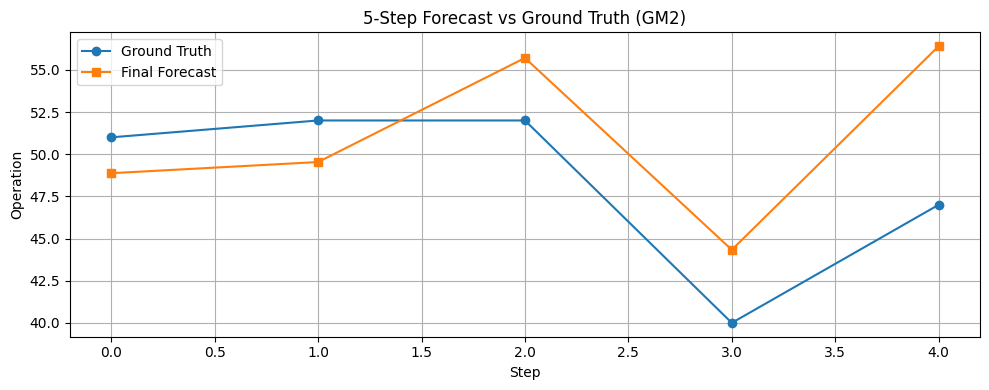

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# =========================================================
# 1) Read last 5 ground-truth values
# =========================================================
gt_path = "/content/GH2_check.xlsx"
gt_df = pd.read_excel(gt_path)

# If there is a DateTime column, set it as index (optional)
if "DateTime" in gt_df.columns:
    gt_df["DateTime"] = pd.to_datetime(gt_df["DateTime"])
    gt_df = gt_df.set_index("DateTime")

# Take last 5 true values
gt_last_5 = gt_df["Operation"].iloc[-5:].reset_index(drop=True)
print("Ground truth (last 5):")
print(gt_last_5)

# =========================================================
# 2) Take your final forecasts (already computed)
# =========================================================
forecast_last_5 = final_forecasts["final_forecast"].reset_index(drop=True)

# Safety alignment
n = min(len(gt_last_5), len(forecast_last_5))
gt_last_5 = gt_last_5.iloc[:n]
forecast_last_5 = forecast_last_5.iloc[:n]

# =========================================================
# 3) Calculate MAE and MAPE
# =========================================================
mae = mean_absolute_error(gt_last_5, forecast_last_5)

mape = np.mean(
    np.abs((gt_last_5 - forecast_last_5) / gt_last_5.replace(0, np.nan))
) * 100

print("\n==============================")
print("Forecast Evaluation (5 steps)")
print("==============================")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f} %")

# =========================================================
# 4) Plot Forecast vs Ground Truth
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(gt_last_5.values, marker="o", label="Ground Truth")
plt.plot(forecast_last_5.values, marker="s", label="Final Forecast")
plt.title("5-Step Forecast vs Ground Truth (GM2)")
plt.xlabel("Step")
plt.ylabel("Operation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
